In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"



In [39]:
delta_min = 5                    
T_hours = 12                      
steps = int((T_hours * 60) / delta_min)
G_target = 100.0                   


In [40]:

params = {
    "G_b": 280.0,    
    "I_b": 0.0,     
    "p1": 0.015,      
    "p2": 0.025,     
    "p3": 0.0006,  
    "n": 0.1,       
    "Vg": 0.6,       
    "Vi": 0.12,      
}

In [41]:

def meal_ra_profile(total_carbs_g, t0_min, time_vector_min, tau_rise=30, tau_decay=90):

    t = np.array(time_vector_min)
    ra = np.zeros_like(t, dtype=float)
    if total_carbs_g <= 0:
        return ra
    scale = 0.05
    amplitude = total_carbs_g * scale
    for i, ti in enumerate(t):
        dt = ti - t0_min
        if dt >= 0:
            ra[i] = amplitude * (dt / (tau_rise + 1e-9)) * np.exp(1 - dt / tau_decay)
            if ra[i] < 0:
                ra[i] = 0.0
    return ra


In [42]:

def simulate_bergman_discrete(params, delta_min, steps, Ra, U, G_start=90.0, noise_std_G=0.0):    

    dt = delta_min
    times = np.arange(0, steps * dt, dt)
    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)
    G[0] = G_start
    X[0] = 0.0
    I[0] = params["I_b"]
    for k in range(steps - 1):
        g = G[k]
        x = X[k]
        i = I[k]
        ra_k = Ra[k]
        u_k = U[k]
        dG = -params["p1"] * (g - params["G_b"]) - x * g + (1.0 / params["Vg"]) * ra_k
        dX = -params["p2"] * x + params["p3"] * (i - params["I_b"])
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]        
        G[k+1] = g + dt * dG + np.random.normal(0.0, noise_std_G)
        X[k+1] = x + dt * dX
        I[k+1] = i + dt * dI
        if G[k+1] < 20.0:
            G[k+1] = 20.0
    df = pd.DataFrame({
        "time_min": times,
        "G": G,
        "X": X,
        "I": I,
        "Ra": Ra[:steps],
        "U": U[:steps],
    })
    return df


In [43]:


def generate_cgm_from_true(G_series, delay_min=15, noise_std=1.0, drift_per_hour=0.0, delta_min=5):

    steps = len(G_series)
    delay_steps = int(delay_min / delta_min)
    cgm = np.zeros(steps)
    for k in range(steps):
        idx = max(0, k - delay_steps)
        base = G_series[idx]
        noise = np.random.normal(0.0, noise_std)
        drift = (k * delta_min / 60.0) * drift_per_hour
        cgm[k] = base + noise + drift
    return cgm



Symulacja samego bergmana, algorytm dąży do 280mg/dL co symuluje działanie organizmu osoby z ct1, gdzie nie występuje naturalne wyrównanie cukrów

In [44]:

# --- Przygotowanie symulacji: czas, posiłek, insulina ---
time_vector = np.arange(0, steps * delta_min, delta_min)
meal_time_min = 30
carbs_g = 0.0
Ra_profile = meal_ra_profile(carbs_g, 0, time_vector)
bolus_events = [(meal_time_min, 0)]
U_profile = np.zeros_like(time_vector)

In [45]:

# --- Uruchomienie symulacji ---
np.random.seed(42)
df = simulate_bergman_discrete(params, delta_min, steps, Ra_profile, U_profile, G_start=90.0)
df["CGM"] = generate_cgm_from_true(df["G"].values, delay_min=10, noise_std=2.0, drift_per_hour=0.2, delta_min=delta_min)


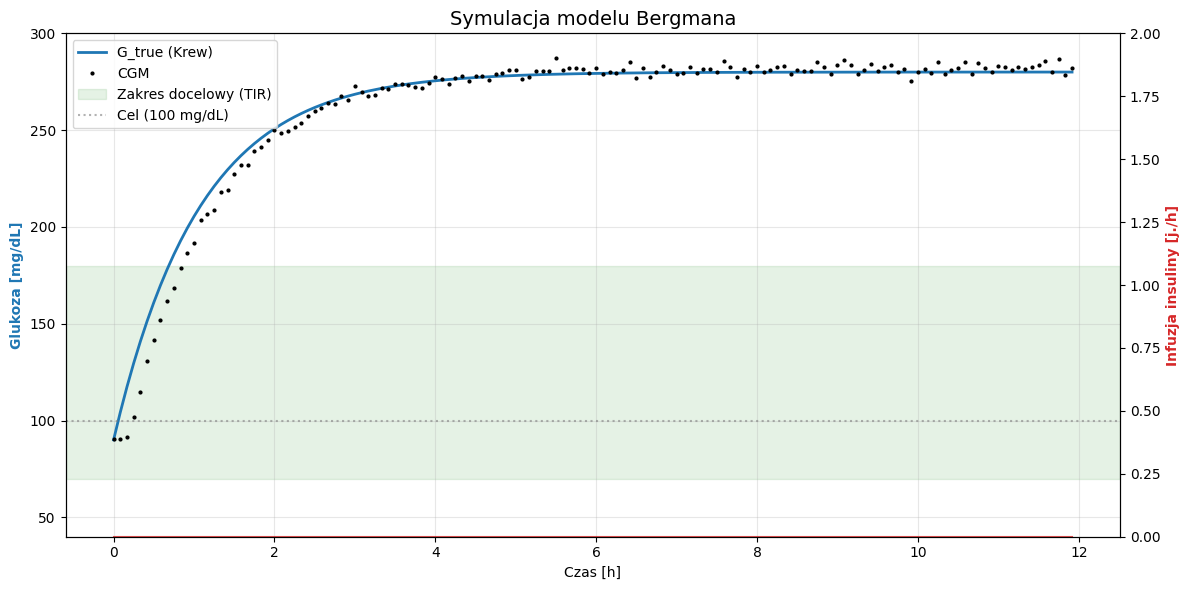

In [46]:
# Przygotowanie osi czasu i danych
time_h = df["time_min"] / 60.0
insulin_h = df["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h, df["CGM"], color='black', alpha=1, label='CGM', marker='o', markersize=2, linestyle='None')
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100 mg/dL)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja modelu Bergmana', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\bergman.pdf", bbox_inches="tight")

Regulator PID

In [47]:
def pid_controller(G_measured, G_target, dt, Kp, Ki, Kd, integral_prev, error_prev, max_U=0.1):

    error = G_measured - G_target
    integral = integral_prev + error * dt
    integral = max(min(integral, 10000), -10000) 

    derivative = (error - error_prev) / dt

    U = Kp * error + Ki * integral + Kd * derivative
    
    U_sat = max(0.0, min(U, max_U))
    if U != U_sat:
        integral = integral_prev 

    return U_sat, integral, error

In [48]:
def simulate_pid_a(params, Kp, Ki, Kd, delay_min=15, noise_std=2.0, drift_per_hour=0.2):
    dt = delta_min
    times = np.arange(0, steps * dt, dt)
    delay_steps = int(delay_min / dt)

    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    G[0] = 90.0 
    X[0] = 0.0
    I[0] = 0.0
    
    integral = 0.0
    error_prev = 0.0

    for k in range(steps - 1):
        idx_delayed = max(0, k - delay_steps)
        noise = np.random.normal(0.0, noise_std)
        drift = (k * dt / 60.0) * drift_per_hour
        CGM[k] = G[idx_delayed] + noise + drift

        U[k], integral, error_prev = pid_controller(
            CGM[k], G_target, dt, Kp, Ki, Kd, integral, error_prev
        )

        g, x, i = G[k], X[k], I[k]
        
        dG = -params["p1"] * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + params["p3"] * i
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]

        G[k+1] = g + dt * dG
        X[k+1] = x + dt * dX
        I[k+1] = i + dt * dI

    CGM[-1] = G[max(0, (steps-1)-delay_steps)] + np.random.normal(0.0, noise_std)

    return pd.DataFrame({"time_min": times, "G": G, "CGM": CGM, "U": U})

In [49]:
Kp = 0.0004
Ki = 0.000005
Kd = 0.008
G_target = 100

In [50]:
df_pid_a = simulate_pid_a(params, Kp, Ki, Kd)

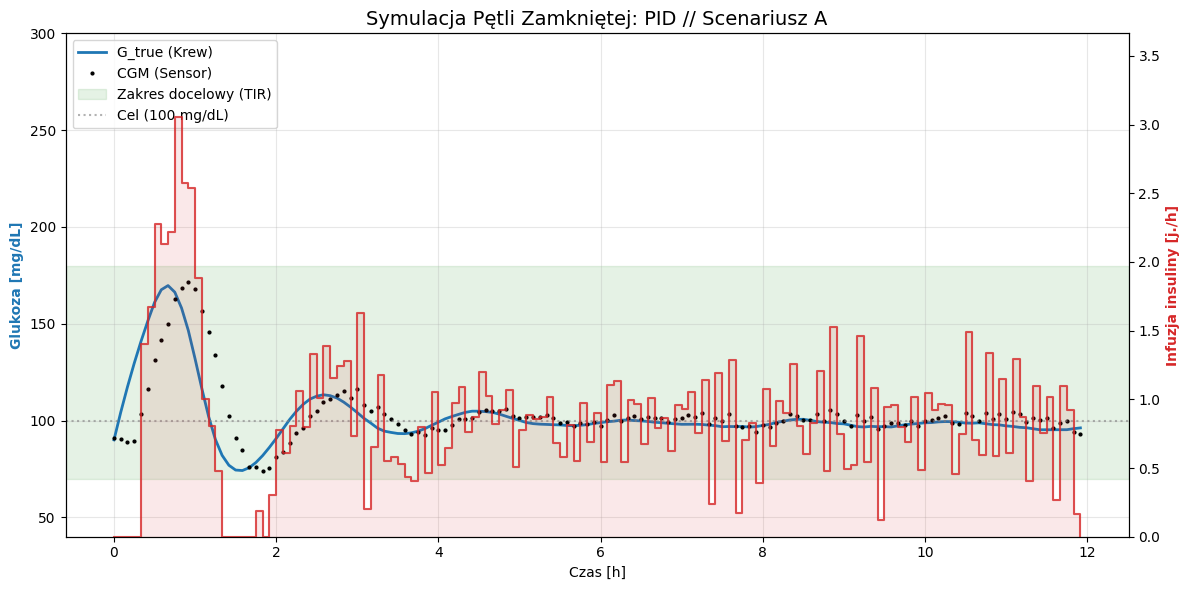

In [51]:
# Przygotowanie osi czasu i danych
time_h = df_pid_a["time_min"] / 60.0
insulin_h = df_pid_a["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_pid_a["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h, df_pid_a["CGM"], color='black', alpha=1, label='CGM (Sensor)',  marker='o', markersize=2, linestyle='None')
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100 mg/dL)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja Pętli Zamkniętej: PID // Scenariusz A', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\pid_A.pdf", bbox_inches="tight")

In [52]:
# --- Scenariusz B: Reakcja na posiłek 20g węglowodanów dla regulatora PID ---

def simulate_scenario_b(params, Kp, Ki, Kd, meal_carbs=0.0, meal_time_min=240):
    dt = delta_min
    times = np.arange(0, steps * dt, dt)
    delay_steps = int(15 / dt) # 10 min opóźnienia CGM

    # Wygenerowanie profilu pojawiania się glukozy z posiłku
    Ra = meal_ra_profile(meal_carbs, meal_time_min, times)

    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    G[0] = 90.0 # Startujemy w stanie ustalonym
    integral = 0.0
    error_prev = 0.0

    for k in range(steps - 1):
        # 1. Odczyt CGM (z opóźnieniem i szumem)
        idx_delayed = max(0, k - delay_steps)
        CGM[k] = G[idx_delayed] + np.random.normal(0.0, 2.0) + (k * dt / 60.0) * 0.2

        # 2. PID reaguje na CGM
        U[k], integral, error_prev = pid_controller(
            CGM[k], G_target, dt, Kp, Ki, Kd, integral, error_prev
        )

        # 3. Model Bergmana z uwzględnieniem posiłku (Ra)
        g, x, i = G[k], X[k], I[k]
        
        # Kluczowa zmiana: dodajemy wpływ posiłku (Ra[k])
        dG = -params["p1"] * (g - params["G_b"]) - x * g + (1.0 / params["Vg"]) * Ra[k]
        dX = -params["p2"] * x + params["p3"] * i
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]

        G[k+1] = g + dt * dG
        X[k+1] = x + dt * dX
        I[k+1] = i + dt * dI

    return pd.DataFrame({"time_min": times, "G": G, "CGM": CGM, "U": U, "Ra": Ra})

# Uruchomienie
df_pid_b = simulate_scenario_b(params, Kp, Ki, Kd, meal_carbs=50.0)

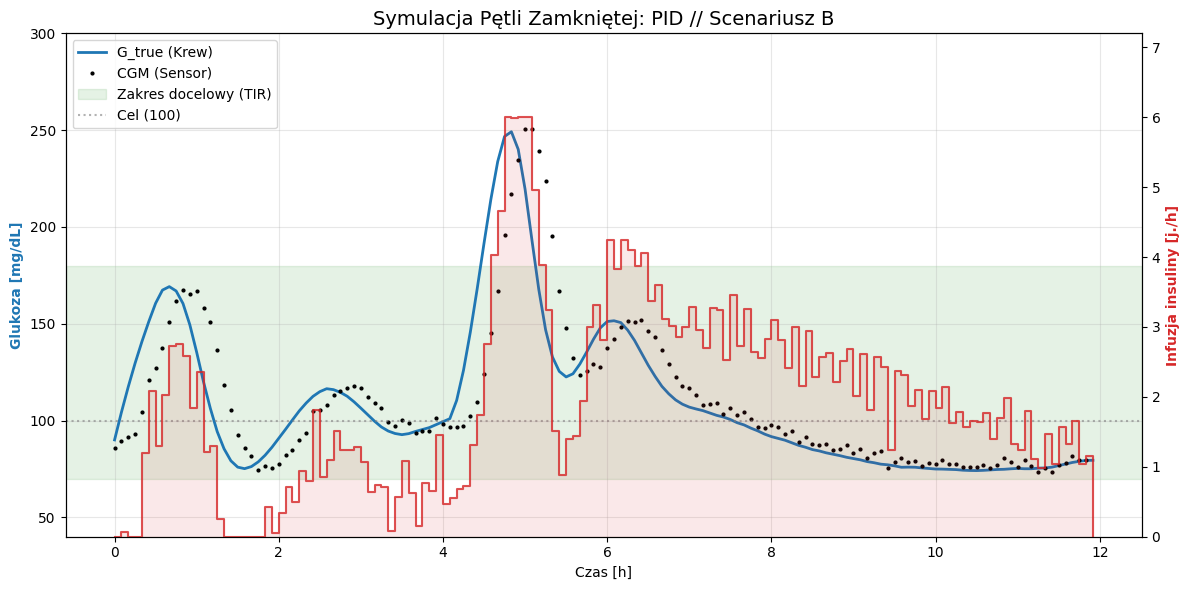

In [53]:
# Przygotowanie osi czasu i danych
time_h = df_pid_b["time_min"] / 60.0
insulin_h = df_pid_b["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_pid_b["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h, df_pid_b["CGM"], color='black', alpha=1, label='CGM (Sensor)', marker='o', markersize=2, linestyle='None')
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja Pętli Zamkniętej: PID // Scenariusz B', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\pid_B.pdf", bbox_inches="tight")

In [54]:
# --- Scenariusz C: Wysiłek fizyczny dla regulatora PID ---
def simulate_scenario_c_exercise(params, Kp, Ki, Kd, exercise_start=240, exercise_duration=60):
    dt = delta_min
    times = np.arange(0, steps * dt, dt)
    delay_steps = int(15 / dt) # Testujemy przy większym lagu 15 min

    G, X, I, U, CGM = np.zeros(steps), np.zeros(steps), np.zeros(steps), np.zeros(steps), np.zeros(steps)
    G[0] = 90.0
    integral, error_prev = 0.0, 0.0

    for k in range(steps - 1):
        # --- DYNAMIKA PARAMETRÓW (Wysiłek fizyczny) ---
        current_p3 = params["p3"]
        current_p1 = params["p1"]
        
        if exercise_start <= k * dt <= (exercise_start + exercise_duration):
            # Podczas ćwiczeń wrażliwość rośnie np. 3-krotnie
            current_p3 = params["p3"] * 3.0
            current_p1 = params["p1"] * 1.5
        
        # --- MODEL CGM ---
        idx_delayed = max(0, k - delay_steps)
        CGM[k] = G[idx_delayed] + np.random.normal(0.0, 2.0)

        # --- REGULATOR PID ---
        # Tutaj regulator musi wykazać się zdolnością do odcięcia insuliny (U=0)
        U[k], integral, error_prev = pid_controller(
            CGM[k], G_target, dt, Kp, Ki, Kd, integral, error_prev
        )

        # --- MODEL BERGMANA (z dynamicznymi parametrami) ---
        g, x, i = G[k], X[k], I[k]
        dG = -current_p1 * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + current_p3 * i
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]

        G[k+1] = g + dt * dG
        X[k+1] = x + dt * dX
        I[k+1] = i + dt * dI

    return pd.DataFrame({"time_min": times, "G": G, "CGM": CGM, "U": U, "X": X})

df_pid_c = simulate_scenario_c_exercise(params, Kp, Ki, Kd, exercise_start=240, exercise_duration=120)

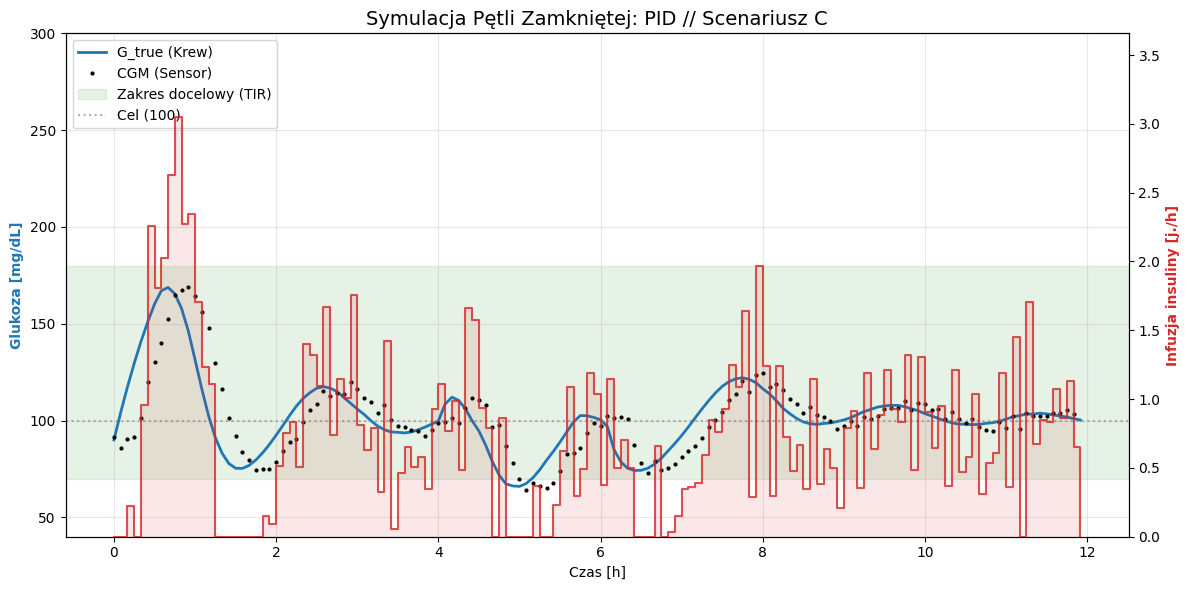

In [55]:
# Przygotowanie osi czasu i danych
time_h = df_pid_c["time_min"] / 60.0
insulin_h = df_pid_c["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_pid_c["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h, df_pid_c["CGM"], color='black', alpha=1, label='CGM (Sensor)', marker='o', markersize=2, linestyle='None')
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja Pętli Zamkniętej: PID // Scenariusz C', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\pid_C.pdf", bbox_inches="tight")

In [56]:
def simulate_scenario_d_noise(params, Kp, Ki, Kd):
    dt = delta_min
    times = np.arange(0, steps * dt, dt)

    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    G[0] = 100.0
    integral = 0.0
    error_prev = 0.0

    delay_steps = int(15 / dt)
    outlier_steps = int(60 / dt)  # outlier co 60 minut

    for k in range(steps - 1):
        # --- GENEROWANIE ZAKŁÓCEŃ CGM ---

        # 1. Szum pomiarowy
        noise = np.random.normal(0.0, 5.0)

        # 2. Dryft sensora: 1 mg/dL na godzinę
        drift = (k * dt / 60.0) * 1.0

        # 3. Błąd odstający co godzinę
        outlier = 0.0
        if k > 0 and k % outlier_steps == 0:
            outlier = np.random.choice([-40.0, 40.0])

        # 4. Odczyt CGM z opóźnieniem 15 minut
        idx_delayed = max(0, k - delay_steps)
        CGM[k] = G[idx_delayed] + noise + drift + outlier

        # --- REGULATOR PID ---
        U[k], integral, error_prev = pid_controller(
            CGM[k],
            G_target,
            dt,
            Kp,
            Ki,
            Kd,
            integral,
            error_prev
        )

        # --- MODEL PACJENTA ---
        g, x, i = G[k], X[k], I[k]

        dG = -params["p1"] * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + params["p3"] * i
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]

        G[k + 1] = g + dt * dG
        X[k + 1] = x + dt * dX
        I[k + 1] = i + dt * dI

        if G[k + 1] < 20.0:
            G[k + 1] = 20.0

    CGM[-1] = CGM[-2]
    U[-1] = U[-2]

    return pd.DataFrame({
        "time_min": times,
        "G": G,
        "CGM": CGM,
        "U": U
    })

df_pid_d = simulate_scenario_d_noise(params, Kp, Ki, Kd)

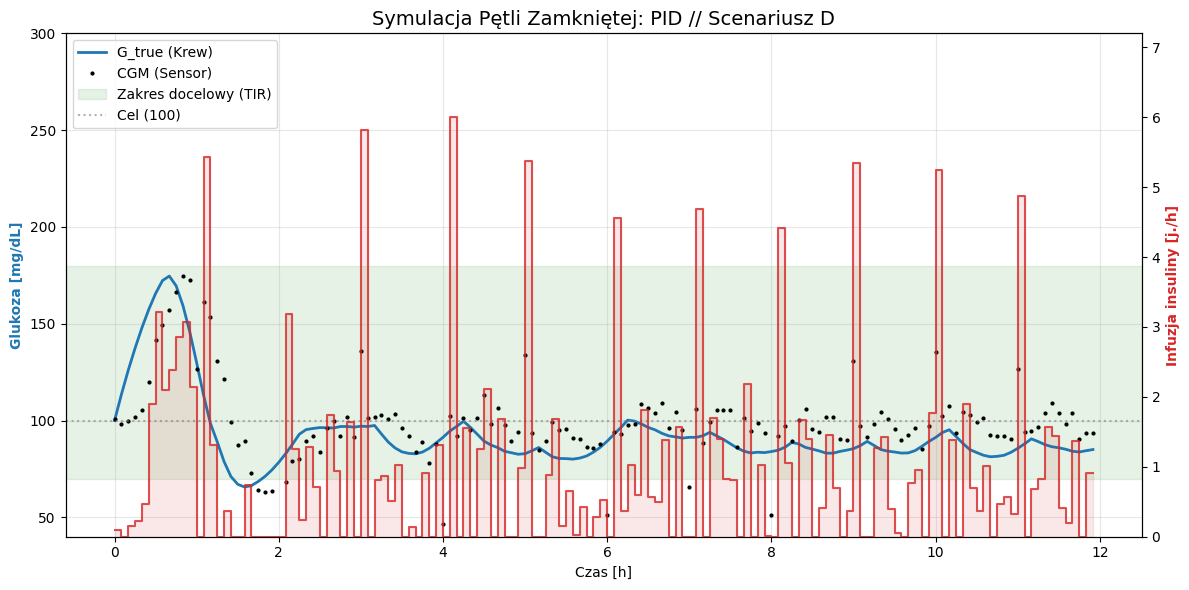

In [57]:
# Przygotowanie osi czasu i danych
time_h = df_pid_d["time_min"] / 60.0
insulin_h = df_pid_d["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_pid_d["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h, df_pid_d["CGM"], color='black', alpha=1, label='CGM (Sensor)', marker='o', markersize=2, linestyle='None')
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja Pętli Zamkniętej: PID // Scenariusz D', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\pid_D.pdf", bbox_inches="tight")

Regulator MPC

In [58]:
from scipy.optimize import minimize


def bergman_predict(y, u, params, dt):
    G, X, I = y
    dG = -params["p1"] * (G - params["G_b"]) - X * G
    dX = -params["p2"] * X + params["p3"] * I
    dI = -params["n"] * I + (1 / params["Vi"]) * u
    return np.array([G + dG*dt, X + dX*dt, I + dI*dt])

def cost_function(u_sequence, current_state_est, target_G, params, horizon, dt, u_prev,
                         lambda_u=10.0, lambda_du=800.0):
    cost = 0.0
    temp_state = current_state_est.copy()

    previous_u = u_prev

    for u in u_sequence:
        temp_state = bergman_predict(temp_state, u, params, dt)

        cost += (temp_state[0] - target_G) ** 2

        cost += lambda_u * (u ** 2)

        cost += lambda_du * ((u - previous_u) ** 2)

        previous_u = u

    return cost

def simulate_mpc_scenario_a(params, lambda_u=10.0, lambda_du=1300.0, max_delta_u=0.01):
    dt_sim = 1.0
    dt_mpc = 5.0
    steps = int((12 * 60) / dt_sim)
    times = np.arange(0, steps * dt_sim, dt_sim)

    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    X_est = 0.0
    I_est = 0.0

    G[0] = 90.0
    u_mpc = 0.013

    delay_steps = int(15 / dt_sim)

    for k in range(steps - 1):

        idx_delayed = max(0, k - delay_steps)
        CGM[k] = G[idx_delayed] + np.random.normal(0.0, 2.0)

        if k % int(dt_mpc / dt_sim) == 0:
            state_est = np.array([CGM[k], X_est, I_est])

            u_init = np.full(12, u_mpc)
            bounds = [(0.0, 0.1) for _ in range(12)]

            res = minimize(
                cost_function,
                u_init,
                args=(state_est, G_target, params, 12, dt_mpc, u_mpc, lambda_u, lambda_du),
                bounds=bounds,
                method="L-BFGS-B"
            )

            u_new = res.x[0]

            u_mpc = np.clip(
                u_new,
                u_mpc - max_delta_u,
                u_mpc + max_delta_u
            )

            u_mpc = float(np.clip(u_mpc, 0.0, 0.1))

        U[k] = u_mpc

        res_est = bergman_predict([CGM[k], X_est, I_est], U[k], params, dt_sim)
        X_est, I_est = res_est[1], res_est[2]

        dG = -params["p1"] * (G[k] - params["G_b"]) - X[k] * G[k]
        dX = -params["p2"] * X[k] + params["p3"] * I[k]
        dI = -params["n"] * I[k] + (1 / params["Vi"]) * U[k]

        G[k + 1] = G[k] + dt_sim * dG
        X[k + 1] = X[k] + dt_sim * dX
        I[k + 1] = I[k] + dt_sim * dI

    CGM[-1] = CGM[-2]

    return pd.DataFrame({
        "time_min": times,
        "G": G,
        "CGM": CGM,
        "U": U
    })
    
df_mpc_a = simulate_mpc_scenario_a(params)

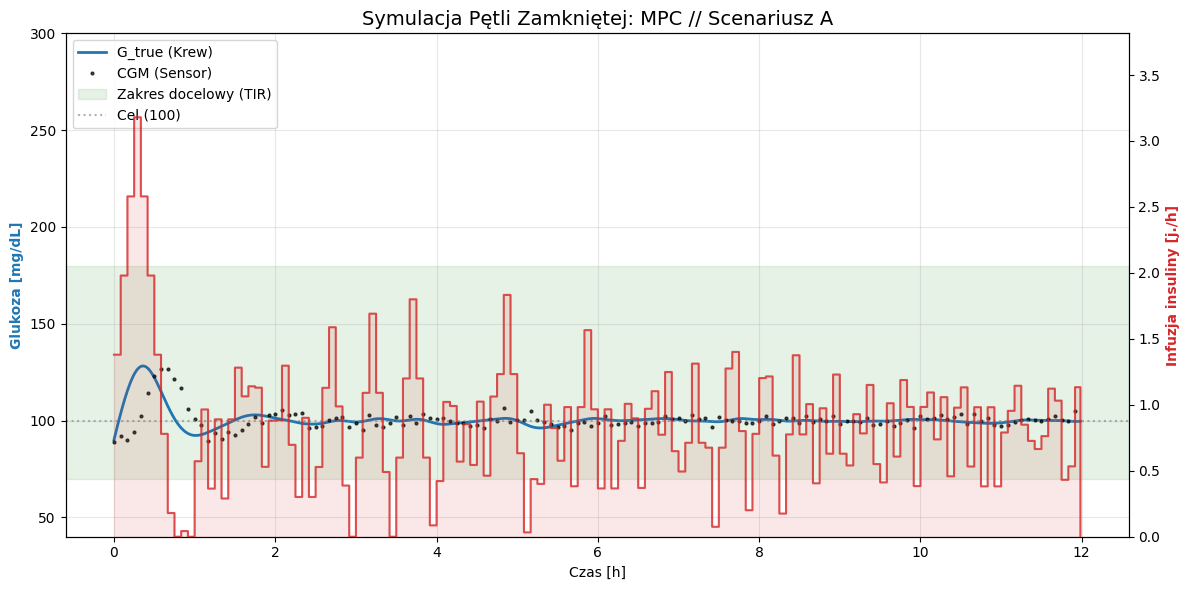

In [59]:
# Przygotowanie osi czasu i danych
time_h = df_mpc_a["time_min"] / 60.0
insulin_h = df_mpc_a["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_mpc_a["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h[::5], df_mpc_a["CGM"][::5], color='black', alpha=0.7, 
         label='CGM (Sensor)', linestyle='', marker='o', markersize=2)
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja Pętli Zamkniętej: MPC // Scenariusz A', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\mpc_A.pdf", bbox_inches="tight")

In [60]:
def simulate_mpc_scenario_b(params, meal_carbs=50.0, meal_time_min=240):
    dt_sim = 1.0
    dt_mpc = 5.0
    steps = int((12 * 60) / dt_sim)
    times = np.arange(0, steps * dt_sim, dt_sim)

    # Profil posiłku
    Ra = meal_ra_profile(meal_carbs, meal_time_min, times)

    # Rzeczywiste stany pacjenta
    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    # Estymowane stany dla MPC
    X_est = 0.0
    I_est = 0.0

    G[0] = 90.0
    u_mpc = 0.013

    delay_steps = int(15 / dt_sim)

    for k in range(steps - 1):

        # --- 1. Sensor CGM ---
        idx_delayed = max(0, k - delay_steps)
        CGM[k] = G[idx_delayed] + np.random.normal(0.0, 2.0)

        # --- 2. Regulator MPC co 5 minut ---
        if k % int(dt_mpc / dt_sim) == 0:
            state_est = np.array([CGM[k], X_est, I_est])

            u_init = np.full(12, u_mpc)
            bounds = [(0.0, 0.1) for _ in range(12)]

            res = minimize(
                cost_function,
                u_init,
                args=(state_est, G_target, params, 12, dt_mpc, u_mpc),
                bounds=bounds,
                method="L-BFGS-B"
            )

            u_mpc = res.x[0]

        U[k] = u_mpc

        # --- 3. Estymator MPC ---
        res_est = bergman_predict([CGM[k], X_est, I_est], U[k], params, dt_sim)
        X_est, I_est = res_est[1], res_est[2]

        # --- 4. Model rzeczywistego pacjenta z posiłkiem ---
        g, x, i = G[k], X[k], I[k]

        dG = -params["p1"] * (g - params["G_b"]) - x * g + (1.0 / params["Vg"]) * Ra[k]
        dX = -params["p2"] * x + params["p3"] * i
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]

        G[k + 1] = g + dt_sim * dG
        X[k + 1] = x + dt_sim * dX
        I[k + 1] = i + dt_sim * dI

    return pd.DataFrame({
        "time_min": times,
        "G": G,
        "CGM": CGM,
        "U": U,
        "Ra": Ra
    })
# Uruchomienie
df_mpc_b = simulate_mpc_scenario_b(params, meal_carbs=50.0)



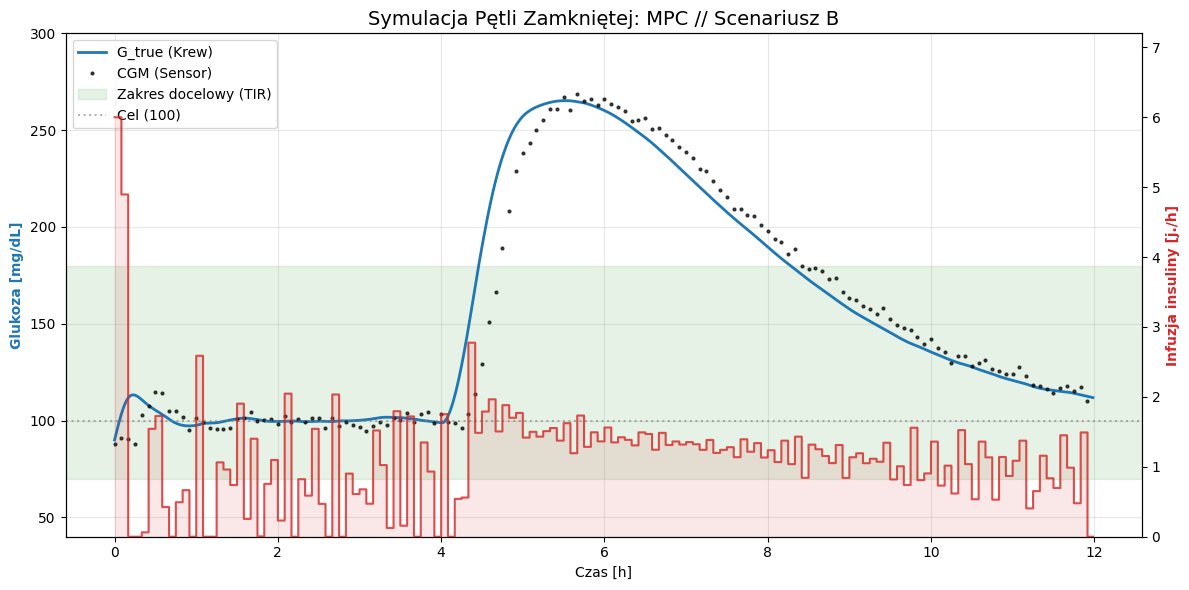

In [61]:
# Przygotowanie osi czasu i danych
time_h = df_mpc_b["time_min"] / 60.0
insulin_h = df_mpc_b["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_mpc_b["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h[::5], df_mpc_b["CGM"][::5], color='black', alpha=0.7, 
         label='CGM (Sensor)', linestyle='', marker='o', markersize=2)
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja Pętli Zamkniętej: MPC // Scenariusz B', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\mpc_B.pdf", bbox_inches="tight")

In [62]:
def simulate_mpc_scenario_c(
    params,
    exercise_start=240,
    exercise_duration=120,
    lambda_u=10.0,
    lambda_du=1300.0,
    max_delta_u=0.01
):
    dt_sim = 1.0
    dt_mpc = 5.0
    steps = int((12 * 60) / dt_sim)
    times = np.arange(0, steps * dt_sim, dt_sim)

    # Rzeczywiste stany pacjenta
    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    # Estymowane stany dla MPC
    X_est = 0.0
    I_est = 0.0

    G[0] = 100.0
    u_mpc = 0.013

    delay_steps = int(15 / dt_sim)

    for k in range(steps - 1):

        # --- 1. Odczyt CGM ---
        idx_delayed = max(0, k - delay_steps)
        CGM[k] = G[idx_delayed] + np.random.normal(0.0, 1.5)

        # --- 2. Zmiana fizjologii pacjenta podczas wysiłku ---
        if exercise_start <= k * dt_sim <= (exercise_start + exercise_duration):
            current_p3 = params["p3"] * 3.0
            current_p1 = params["p1"] * 1.5
        else:
            current_p3 = params["p3"]
            current_p1 = params["p1"]

        # --- 3. Regulator MPC co 5 minut ---
        if k % int(dt_mpc / dt_sim) == 0:
            state_est = np.array([CGM[k], X_est, I_est])

            h = 12
            u_init = np.full(h, u_mpc)
            bounds = [(0.0, 0.1) for _ in range(h)]

            # MPC używa standardowego modelu params,
            # nie wie o czasowej zmianie p1 i p3 podczas wysiłku
            res = minimize(
                cost_function,
                u_init,
                args=(state_est, G_target, params, h, dt_mpc, u_mpc, lambda_u, lambda_du),
                bounds=bounds,
                method="L-BFGS-B"
            )

            u_new = res.x[0]

            # Dodatkowe ograniczenie zmiany dawki
            u_mpc = np.clip(
                u_new,
                u_mpc - max_delta_u,
                u_mpc + max_delta_u
            )

            u_mpc = float(np.clip(u_mpc, 0.0, 0.1))

        U[k] = u_mpc

        # --- 4. Aktualizacja estymatora MPC ---
        res_est = bergman_predict([CGM[k], X_est, I_est], U[k], params, dt_sim)
        X_est, I_est = res_est[1], res_est[2]

        # --- 5. Rzeczywisty pacjent z dynamiczną fizjologią ---
        g, x, i = G[k], X[k], I[k]

        dG = -current_p1 * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + current_p3 * i
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]

        G[k + 1] = g + dt_sim * dG
        X[k + 1] = x + dt_sim * dX
        I[k + 1] = i + dt_sim * dI

        if G[k + 1] < 20.0:
            G[k + 1] = 20.0

    CGM[-1] = CGM[-2]
    U[-1] = U[-2]

    return pd.DataFrame({
        "time_min": times,
        "G": G,
        "CGM": CGM,
        "U": U
    })

# Uruchomienie
df_mpc_c = simulate_mpc_scenario_c(params)

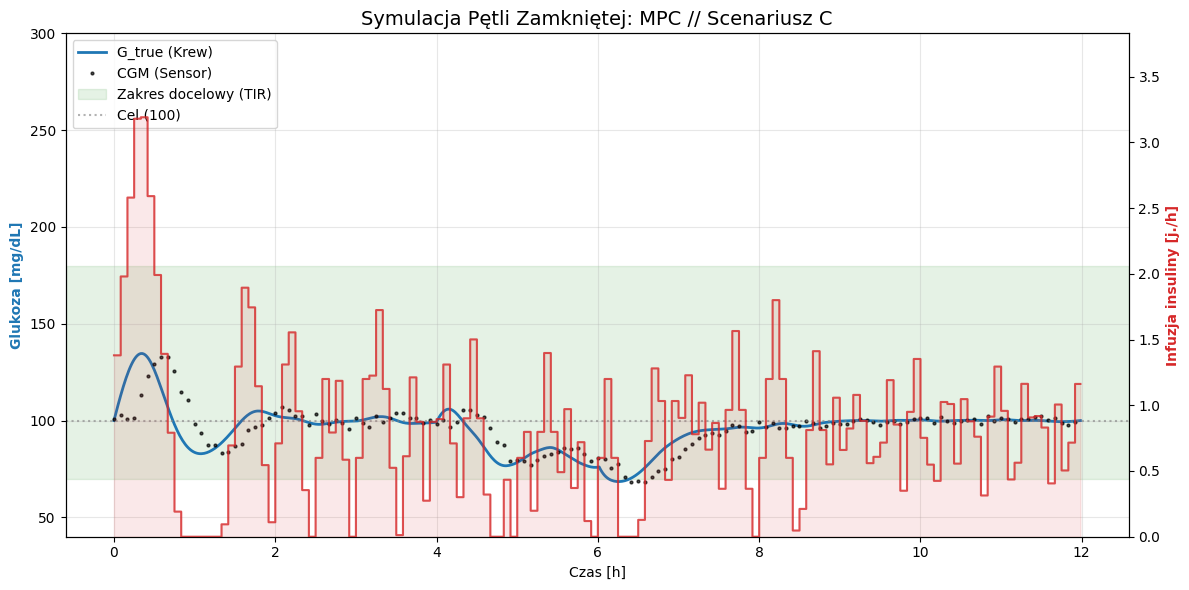

In [63]:
# Przygotowanie osi czasu i danych
time_h = df_mpc_c["time_min"] / 60.0
insulin_h = df_mpc_c["U"] * 60.0 # Przeliczenie na j./h dla czytelności

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_mpc_c["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)
ax1.plot(time_h[::5], df_mpc_c["CGM"][::5], color='black', alpha=0.7, 
         label='CGM (Sensor)', linestyle='', marker='o', markersize=2)
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 2.0))

plt.title('Symulacja Pętli Zamkniętej: MPC // Scenariusz C', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\mpc_C.pdf", bbox_inches="tight")

In [64]:
def simulate_mpc_scenario_d(
    params,
    G_target=100.0,
    lambda_u=10.0,
    lambda_du=1300.0,
    max_delta_u=0.01
):
    dt_sim = 1.0
    dt_mpc = 5.0
    steps = int((12 * 60) / dt_sim)
    times = np.arange(0, steps * dt_sim, dt_sim)

    # Stany rzeczywiste
    G = np.zeros(steps)
    X = np.zeros(steps)
    I = np.zeros(steps)

    # Sygnały
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    # Estymowane stany dla MPC
    X_est = 0.0
    I_est = 0.0

    # Warunki początkowe
    G[0] = 100.0
    u_mpc = 0.013

    delay_steps = int(15 / dt_sim)

    for k in range(steps - 1):

        # --- 1. GENEROWANIE ZAKŁÓCEŃ CGM ---
        noise = np.random.normal(0.0, 5.0)          # zwiększony szum
        drift = (k * dt_sim / 60.0) * 1.0           # dryft 1 mg/dL/h

        outlier = 0.0
        if k % 60 == 0:
            outlier = np.random.choice([-40.0, 40.0])

        idx_delayed = max(0, k - delay_steps)

        CGM[k] = G[idx_delayed] + noise + drift + outlier

        # --- 2. REGULATOR MPC CO 5 MINUT ---
        if k % int(dt_mpc / dt_sim) == 0:
            state_est = np.array([CGM[k], X_est, I_est])

            h = 24
            u_init = np.full(h, u_mpc)
            bounds = [(0.0, 0.1) for _ in range(h)]

            res = minimize(
                cost_function,
                u_init,
                args=(state_est, G_target, params, h, dt_mpc, u_mpc, lambda_u, lambda_du),
                bounds=bounds,
                method="L-BFGS-B"
            )

            u_new = res.x[0]

            # Twarde ograniczenie zmiany dawki
            u_mpc = np.clip(
                u_new,
                u_mpc - max_delta_u,
                u_mpc + max_delta_u
            )

            u_mpc = float(np.clip(u_mpc, 0.0, 0.1))

        U[k] = u_mpc

        # --- 3. AKTUALIZACJA ESTYMATORA MPC ---
        # Estymator korzysta z przekłamanego CGM, tak jak regulator
        res_est = bergman_predict([CGM[k], X_est, I_est], U[k], params, dt_sim)
        X_est, I_est = res_est[1], res_est[2]

        # --- 4. RZECZYWISTA FIZJOLOGIA PACJENTA ---
        g, x, i = G[k], X[k], I[k]

        dG = -params["p1"] * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + params["p3"] * i
        dI = -params["n"] * i + (1 / params["Vi"]) * U[k]

        G[k + 1] = g + dt_sim * dG
        X[k + 1] = x + dt_sim * dX
        I[k + 1] = i + dt_sim * dI

        if G[k + 1] < 20.0:
            G[k + 1] = 20.0

    CGM[-1] = CGM[-2]
    U[-1] = U[-2]

    return pd.DataFrame({
        "time_min": times,
        "G": G,
        "CGM": CGM,
        "U": U
    })
# Uruchomienie
df_mpc_d = simulate_mpc_scenario_d(params)

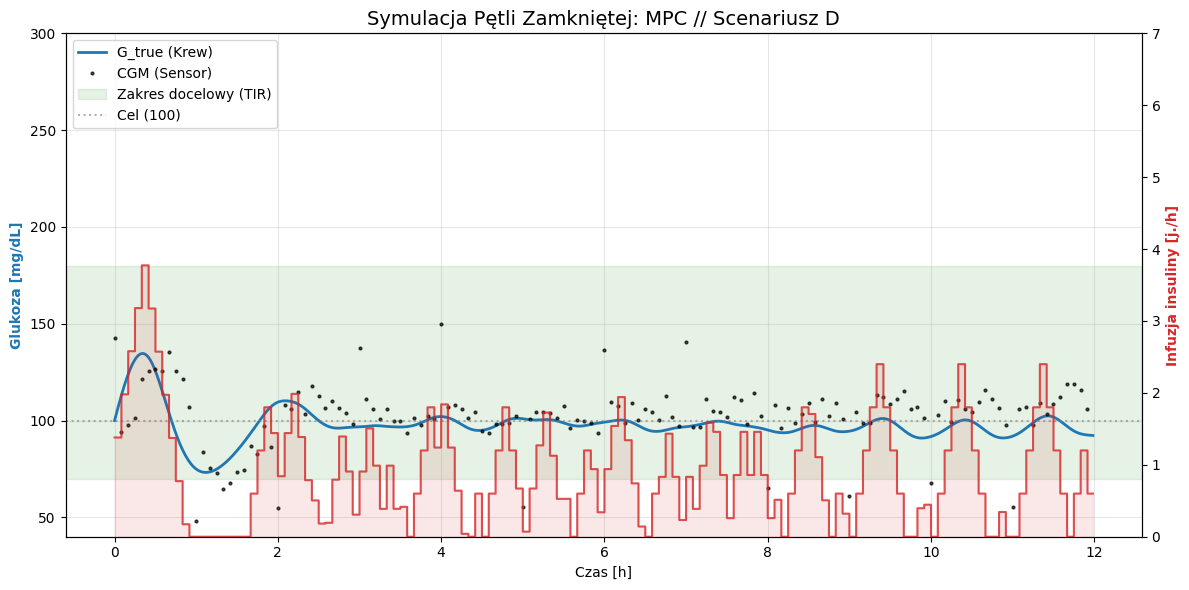

In [65]:
# Przygotowanie osi czasu i danych
time_h = df_mpc_d["time_min"] / 60.0
insulin_h = df_mpc_d["U"] * 60.0 

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- OŚ GLUKOZY ---
ax1.set_xlabel('Czas [h]')
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')

# Prawdziwa glukoza (linia ciągła - zostawiamy co minutę dla gładkości)
ax1.plot(time_h, df_mpc_d["G"], color='tab:blue', label='G_true (Krew)', linewidth=2)

# CGM wyświetlany co 5 minut (kropki połączone linią przerywaną)
# Używamy [::5], aby pokazać tylko te punkty, które MPC faktycznie "widzi"
ax1.plot(time_h[::5], df_mpc_d["CGM"][::5], color='black', alpha=0.7, 
         label='CGM (Sensor)', linestyle='', marker='o', markersize=2)

ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(G_target, color='gray', linestyle=':', alpha=0.6, label='Cel (100)')
ax1.set_ylim(40, 300)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- OŚ INSULINY ---
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')

# Wykres schodkowy dla insuliny (step) idealnie oddaje naturę MPC
ax2.step(time_h, insulin_h, color='tab:red', where='post', alpha=0.8, label='Podawana insulina')
ax2.fill_between(time_h, insulin_h, step="post", alpha=0.1, color='tab:red')
ax2.set_ylim(0, max(insulin_h.max() * 1.2, 7.0)) # Zwiększony limit dla widoczności "strzałów"

plt.title('Symulacja Pętli Zamkniętej: MPC // Scenariusz D', fontsize=14)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\mpc_D.pdf", bbox_inches="tight")

Model RL — trening wieloscenariuszowy (A spoczynek + B posiłek + C wysiłek + D szum CGM). Po zmianie kodu uruchom komórkę z sieciami i treningiem (~800 epizodów), potem symulacje B/C/D.

In [66]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

MAX_U = 0.06          
MAX_DELTA_U = 0.003   
G_TARGET = 100.0

state_dim = 4        
action_dim = 1

batch_size = 64
gamma = 0.99

TAU = 0.005         
POLICY_DELAY = 2 

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Actor, self).__init__()

        self.layer = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layer(x) * MAX_U


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()

        self.layer = nn.Sequential(
            nn.Linear(state_dim + action_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, state, action):
        return self.layer(torch.cat([state, action], dim=1))


# ============================================================
# 4. INICJALIZACJA AKTORA DAWKĄ BAZALNĄ
# ============================================================

def initialize_actor_to_basal(actor, basal_u=0.013):
    """
    Ustawia ostatnią warstwę aktora tak, aby na początku
    zwracał dawkę zbliżoną do dawki bazalnej.
    """
    with torch.no_grad():
        last_linear = actor.layer[-2]  # ostatnia warstwa Linear przed Sigmoid

        last_linear.weight.zero_()

        p = np.clip(basal_u / MAX_U, 1e-4, 1.0 - 1e-4)
        bias_value = np.log(p / (1.0 - p))

        last_linear.bias.fill_(bias_value)


# ============================================================
# 5. UTWORZENIE SIECI I OPTYMALIZATORÓW
# ============================================================

actor = Actor(state_dim, action_dim)
initialize_actor_to_basal(actor, basal_u=0.013)

critic = Critic(state_dim, action_dim)

actor_target = Actor(state_dim, action_dim)
critic_target = Critic(state_dim, action_dim)

actor_target.load_state_dict(actor.state_dict())
critic_target.load_state_dict(critic.state_dict())

actor_opt = optim.Adam(actor.parameters(), lr=5e-5)
critic_opt = optim.Adam(critic.parameters(), lr=5e-4)

memory = deque(maxlen=200000)

train_step_counter = 0


# ============================================================
# 6. FUNKCJE POMOCNICZE
# ============================================================

def soft_update(target, source, tau):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.copy_(
            tau * source_param.data + (1.0 - tau) * target_param.data
        )


def limit_insulin_change(u_raw, u_prev):
    """
    Ogranicza zmianę dawki insuliny względem poprzedniej decyzji.
    """
    u_limited = np.clip(
        u_raw,
        u_prev - MAX_DELTA_U,
        u_prev + MAX_DELTA_U
    )

    return float(np.clip(u_limited, 0.0, MAX_U))


def limit_insulin_change_tensor(u_raw, states):
    """
    Wersja tensorowa używana podczas uczenia.
    Poprzednia dawka jest czwartą składową stanu: states[:, 3].
    """
    u_prev = states[:, 3:4] * MAX_U

    u_limited = torch.max(
        torch.min(u_raw, u_prev + MAX_DELTA_U),
        u_prev - MAX_DELTA_U
    )

    return torch.clamp(u_limited, 0.0, MAX_U)


# ============================================================
# 7. MODEL CGM DLA TRENINGU
# ============================================================

def cgm_measurement(G, k, lag_steps, scenario_kind):
    idx = max(0, k - lag_steps)

    if scenario_kind == "sensor":
        noise = np.random.normal(0.0, 5.0)
        drift = (k / 60.0) * 1.0
        outlier = np.random.choice([-40.0, 40.0]) if k % 60 == 0 else 0.0
        return G[idx] + noise + drift + outlier

    return G[idx] + np.random.normal(0.0, 1.2)


# ============================================================
# 8. LOSOWANIE SCENARIUSZY TRENINGOWYCH
# ============================================================

def sample_training_scenario():
    kind = np.random.choice(
        ["rest", "meal", "exercise", "sensor"],
        p=[0.30, 0.30, 0.25, 0.15],
    )

    steps = 720

    cfg = {
        "kind": kind,
        "ra": np.zeros(steps),
        "ex_start": 240,
        "ex_dur": 120
    }

    if kind == "meal":
        cfg["ra"] = meal_ra_profile(
            total_carbs_g=float(np.random.uniform(30.0, 60.0)),
            t0_min=int(np.random.randint(90, 211)),
            time_vector_min=np.arange(steps, dtype=float)
        )

    elif kind == "exercise":
        cfg["ex_start"] = int(np.random.randint(180, 301))
        cfg["ex_dur"] = int(np.random.randint(60, 121))

    return cfg


# ============================================================
# 9. FUNKCJA NAGRODY
# ============================================================

def ddpg_reward(g, u_prev, u_new):

    r = -((g - G_TARGET) ** 2) / 100.0

    if g < 70.0:
        r -= 120.0

    if g < 55.0:
        r -= 300.0

    if g > 180.0:
        r -= (g - 180.0) * 0.3

    r -= 500.0 * (u_new - u_prev) ** 2
    r -= 50.0 * (u_new ** 2)

    return float(r)


# ============================================================
# 10. POJEDYNCZY EPIZOD TRENINGOWY
# ============================================================

def run_training_episode(explore_noise=0.008):
    cfg = sample_training_scenario()

    steps = len(cfg["ra"])
    lag_steps = 15

    G = np.zeros(steps)

    g = float(np.random.uniform(95.0, 115.0))
    x = 0.0
    i = 0.0

    x_est = 0.0
    i_est = 0.0

    G[0] = g

    history_cgm = [g] * 30

    u = 0.013
    u_prev_reward = u

    transitions = []

    state = None
    action_used = None

    for k in range(steps - 1):
        t_min = float(k)

        p1m = 1.0
        p3m = 1.0

        if cfg["kind"] == "exercise":
            if cfg["ex_start"] <= t_min <= (cfg["ex_start"] + cfg["ex_dur"]):
                p1m = 1.5
                p3m = 3.0

        # ---------- Decyzja agenta co 5 minut ----------
        if k % 5 == 0:
            cgm = cgm_measurement(G, k, lag_steps, cfg["kind"])
            history_cgm.append(cgm)

            trend = (cgm - history_cgm[-4]) / 15.0

            state = np.array([
                cgm / 200.0,
                trend / 5.0,
                x_est * 100.0,
                u / MAX_U
            ], dtype=np.float32)

            with torch.no_grad():
                u_raw = actor(torch.FloatTensor(state).unsqueeze(0)).numpy()[0, 0]

            if explore_noise > 0:
                u_raw += np.random.normal(0.0, explore_noise)

            u = limit_insulin_change(u_raw, u)
            action_used = np.array([u], dtype=np.float32)

        # ---------- Model pacjenta ----------
        p1 = params["p1"] * p1m
        p3 = params["p3"] * p3m

        dG = -p1 * (g - params["G_b"]) - x * g + cfg["ra"][k]
        dX = -params["p2"] * x + p3 * (i - params["I_b"])
        dI = -params["n"] * i + (1.0 / params["Vi"]) * u

        g += dG
        x += dX
        i += dI

        if g < 20.0:
            g = 20.0

        G[k + 1] = g

        # ---------- Estymator działania insuliny ----------
        dX_est = -params["p2"] * x_est + params["p3"] * i_est
        dI_est = -params["n"] * i_est + (1.0 / params["Vi"]) * u

        x_est += dX_est
        i_est += dI_est

        # ---------- Zapis przejścia co 5 minut ----------
        if k % 5 == 4 and state is not None:
            cgm_n = cgm_measurement(G, k + 1, lag_steps, cfg["kind"])

            history_next = history_cgm + [cgm_n]
            trend_n = (cgm_n - history_next[-4]) / 15.0

            next_state = np.array([
                cgm_n / 200.0,
                trend_n / 5.0,
                x_est * 100.0,
                u / MAX_U
            ], dtype=np.float32)

            reward = ddpg_reward(g, u_prev_reward, u)
            u_prev_reward = u

            done = (g < 55.0) or (g > 350.0)

            transitions.append((state, action_used, reward, next_state, done))

            if done:
                break

    return transitions


# ============================================================
# 11. STABILNIEJSZY KROK TRENINGOWY
# ============================================================

def train_step():
    global train_step_counter

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.array(states))
    actions = torch.FloatTensor(np.array(actions))
    rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
    next_states = torch.FloatTensor(np.array(next_states))
    dones = torch.FloatTensor(np.array(dones, dtype=np.float32)).unsqueeze(1)

    # ---------- Update Critic ----------
    with torch.no_grad():
        next_actions_raw = actor_target(next_states)
        next_actions = limit_insulin_change_tensor(next_actions_raw, next_states)

        target_q = rewards + gamma * (1.0 - dones) * critic_target(
            next_states,
            next_actions
        )

    current_q = critic(states, actions)

    critic_loss = nn.SmoothL1Loss()(current_q, target_q)

    critic_opt.zero_grad()
    critic_loss.backward()

    torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=1.0)

    critic_opt.step()

    # ---------- Update Actor ----------
    if train_step_counter % POLICY_DELAY == 0:
        actor_actions_raw = actor(states)
        actor_actions = limit_insulin_change_tensor(actor_actions_raw, states)

        actor_loss = -critic(states, actor_actions).mean()

        actor_opt.zero_grad()
        actor_loss.backward()

        torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=1.0)

        actor_opt.step()

        soft_update(actor_target, actor, TAU)
        soft_update(critic_target, critic, TAU)

    train_step_counter += 1


# ============================================================
# 12. TRENING WIELOSCENARIUSZOWY
# ============================================================

memory.clear()
train_step_counter = 0

n_episodes = 1200

for episode in range(n_episodes):
    explore_noise = max(0.001, 0.008 * (1.0 - episode / n_episodes))

    transitions = run_training_episode(explore_noise=explore_noise)

    for transition in transitions:
        memory.append(transition)
        train_step()

    if (episode + 1) % 100 == 0:
        print(f"Epizod {episode + 1}/{n_episodes}, bufor: {len(memory)}")

Epizod 100/1200, bufor: 3477
Epizod 200/1200, bufor: 5460
Epizod 300/1200, bufor: 7321
Epizod 400/1200, bufor: 15421
Epizod 500/1200, bufor: 27436
Epizod 600/1200, bufor: 41736
Epizod 700/1200, bufor: 55496
Epizod 800/1200, bufor: 68710
Epizod 900/1200, bufor: 83010
Epizod 1000/1200, bufor: 97310
Epizod 1100/1200, bufor: 111610
Epizod 1200/1200, bufor: 125910


In [67]:
def simulate_rl_scenario_a(params, actor_model, cgm_lag_min=15):
    steps = 720
    lag_steps = int(cgm_lag_min)

    G = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    g = 100.0
    x = 0.0
    i = 0.0
    G[0] = g
    x_est = 0.0
    i_est = 0.0
    history_cgm_seen = [100.0] * 30

    u_ddpg = 0.013
    current_cgm = 100.0

    CGM[0] = 100.0

    for k in range(steps - 1):
        if k % 5 == 0:
            idx_lag = max(0, k - lag_steps)
            current_cgm = G[idx_lag] + np.random.normal(0.0, 1.2)
            history_cgm_seen.append(current_cgm)
            CGM[k] = current_cgm
            trend = (current_cgm - history_cgm_seen[-4]) / 15.0
            state = np.array([
                current_cgm / 200.0,
                trend / 5.0,
                x_est * 100.0,
                u_ddpg / MAX_U
            ], dtype=np.float32)

            with torch.no_grad():
                u_raw = actor_model(
                    torch.FloatTensor(state).unsqueeze(0)
                ).numpy()[0, 0]

            u_ddpg = limit_insulin_change(u_raw, u_ddpg)
        else:
            CGM[k] = CGM[max(0, k - 1)]
        U[k] = u_ddpg

        dG = -params["p1"] * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + params["p3"] * (i - params["I_b"])
        dI = -params["n"] * i + (1.0 / params["Vi"]) * u_ddpg
        g += dG
        x += dX
        i += dI

        if g < 20.0:
            g = 20.0
        G[k + 1] = g

        dX_est = -params["p2"] * x_est + params["p3"] * i_est
        dI_est = -params["n"] * i_est + (1.0 / params["Vi"]) * u_ddpg
        x_est += dX_est
        i_est += dI_est

    CGM[-1] = CGM[-2]

    return pd.DataFrame({
        "time": np.arange(steps),
        "G": G,
        "U": U,
        "CGM": CGM
    })


df_rl_a = simulate_rl_scenario_a(params, actor)

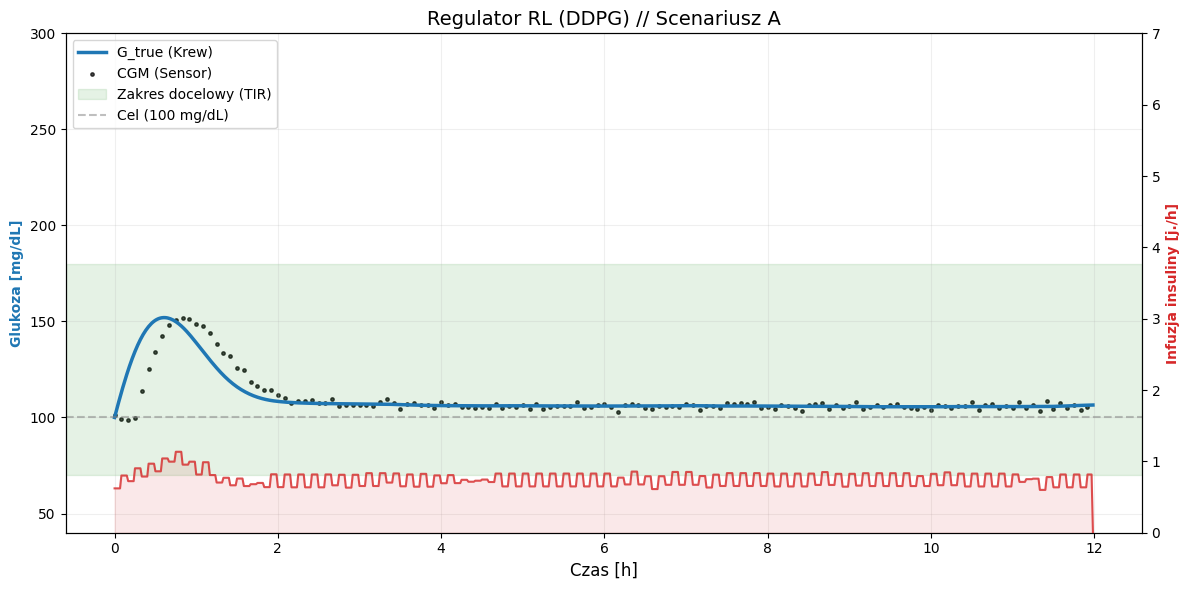

In [68]:
time_h = df_rl_a["time"] / 60.0
insulin_h = df_rl_a["U"] * 60.0 

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]', fontsize=12)
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_rl_a["G"], color='tab:blue', label='G_true (Krew)', linewidth=2.5)

# Rysujemy kropki tylko tam, gdzie faktycznie był pomiar (co 5 minut)
mask = df_rl_a["time"] % 5 == 0
ax1.scatter(time_h[mask], df_rl_a["CGM"][mask], color='black', s=6, alpha=0.7, label='CGM (Sensor)')

ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Cel (100 mg/dL)')
ax1.set_ylim(40, 300)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.plot(time_h, insulin_h, color='tab:red', linewidth=1.5, alpha=0.8, label='DDPG: Dawka ciągła')
ax2.fill_between(time_h, insulin_h, alpha=0.1, color='tab:red')
ax2.set_ylim(0, 7)

plt.title('Regulator RL (DDPG) // Scenariusz A', fontsize=14)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\rl_A.pdf", bbox_inches="tight")

In [69]:
def simulate_rl_scenario_b(params, actor_model, ra_profile, cgm_lag_min=15):
    steps = len(ra_profile)
    lag_steps = int(cgm_lag_min)

    G = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    # Warunki początkowe
    g = 90.0
    x = 0.0
    i = 0.0

    G[0] = g

    # Estymowane stany używane przez regulator
    x_est = 0.0
    i_est = 0.0

    history_cgm_seen = [100.0] * 30

    u_ddpg = 0.013
    current_cgm = 100.0

    CGM[0] = current_cgm

    for k in range(steps - 1):

        # ---------- Odczyt CGM co 5 minut ----------
        if k % 5 == 0:
            idx_lag = max(0, k - lag_steps)

            current_cgm = G[idx_lag] + np.random.normal(0.0, 1.2)
            history_cgm_seen.append(current_cgm)

            CGM[k] = current_cgm

            trend = (current_cgm - history_cgm_seen[-4]) / 15.0

            state = np.array([
                current_cgm / 200.0,
                trend / 5.0,
                x_est * 100.0,
                u_ddpg / MAX_U
            ], dtype=np.float32)

            with torch.no_grad():
                u_raw = actor_model(
                    torch.FloatTensor(state).unsqueeze(0)
                ).numpy()[0, 0]

            # Ograniczenie gwałtownej zmiany dawki
            u_ddpg = limit_insulin_change(u_raw, u_ddpg)

        else:
            CGM[k] = CGM[max(0, k - 1)]

        U[k] = u_ddpg

        # ---------- Model pacjenta z posiłkiem ----------
        dG = (
            -params["p1"] * (g - params["G_b"])
            - x * g
            + ra_profile[k]
        )

        dX = -params["p2"] * x + params["p3"] * (i - params["I_b"])
        dI = -params["n"] * i + (1.0 / params["Vi"]) * u_ddpg

        g += dG
        x += dX
        i += dI

        if g < 20.0:
            g = 20.0

        G[k + 1] = g

        # ---------- Estymator działania insuliny ----------
        dX_est = -params["p2"] * x_est + params["p3"] * i_est
        dI_est = -params["n"] * i_est + (1.0 / params["Vi"]) * u_ddpg

        x_est += dX_est
        i_est += dI_est

    CGM[-1] = CGM[-2]
    U[-1] = U[-2]

    return pd.DataFrame({
        "time": np.arange(steps),
        "G": G,
        "U": U,
        "CGM": CGM,
        "Ra": ra_profile
    })
    
steps_rl = 720
time_rl = np.arange(steps_rl, dtype=float)

ra_values = meal_ra_profile(
    total_carbs_g=50.0,
    t0_min=240,
    time_vector_min=time_rl
)

df_rl_b = simulate_rl_scenario_b(
    params,
    actor,
    ra_values,
    cgm_lag_min=15
)

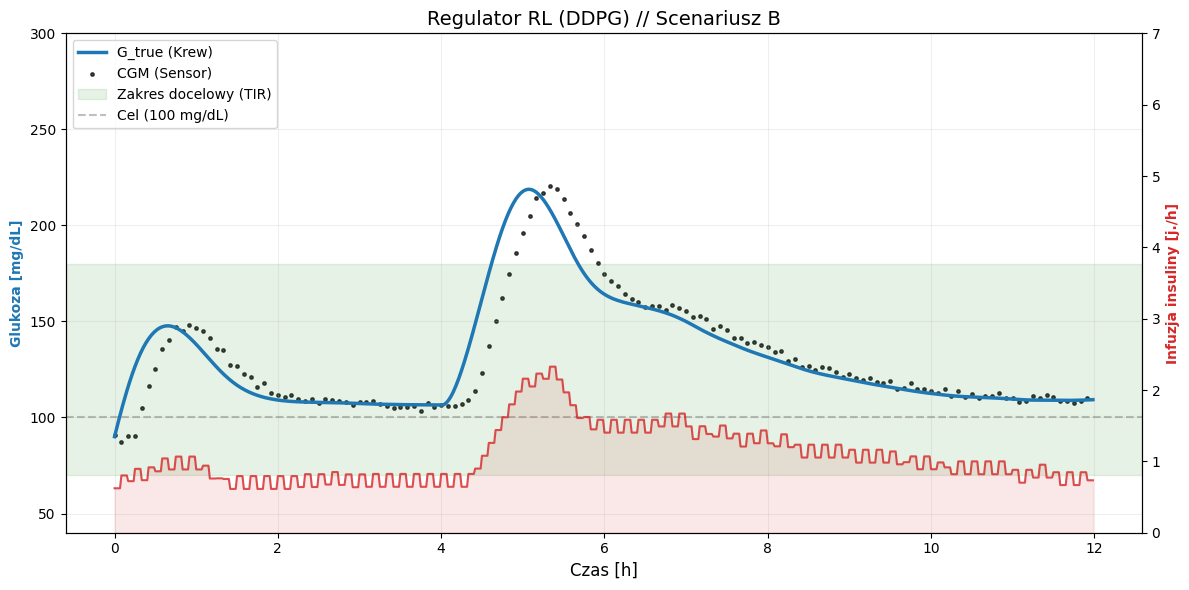

In [70]:
time_h = df_rl_b["time"] / 60.0
insulin_h = df_rl_b["U"] * 60.0 

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]', fontsize=12)
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_rl_b["G"], color='tab:blue', label='G_true (Krew)', linewidth=2.5)

# Rysujemy kropki tylko tam, gdzie faktycznie był pomiar (co 5 minut)
mask = df_rl_b["time"] % 5 == 0
ax1.scatter(time_h[mask], df_rl_b["CGM"][mask], color='black', s=6, alpha=0.7, label='CGM (Sensor)')

ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Cel (100 mg/dL)')
ax1.set_ylim(40, 300)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.plot(time_h, insulin_h, color='tab:red', linewidth=1.5, alpha=0.8, label='DDPG: Dawka ciągła')
ax2.fill_between(time_h, insulin_h, alpha=0.1, color='tab:red')
ax2.set_ylim(0, 7)

plt.title('Regulator RL (DDPG) // Scenariusz B', fontsize=14)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\rl_B.pdf", bbox_inches="tight")

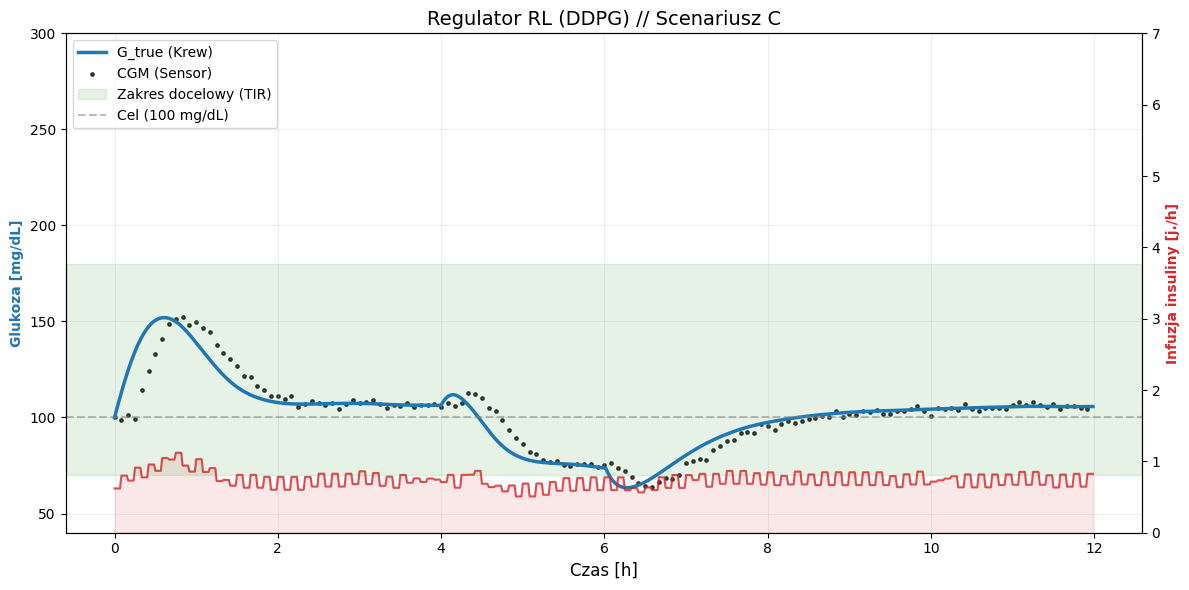

In [71]:
def simulate_rl_scenario_c(
    params,
    actor_model,
    exercise_start=240,
    exercise_duration=120,
    cgm_lag_min=15,
    dt_min=1.0
):
    """
    Scenariusz C: wysiłek fizyczny.
    Agent widzi wyłącznie opóźniony CGM, trend, estymowane działanie insuliny
    oraz poprzednią dawkę. Nie zna bezpośrednio G_true ani zmiany parametrów p1/p3.
    """

    steps = int(12 * 60 / dt_min)
    time_vector = np.arange(steps) * dt_min

    lag_steps = int(cgm_lag_min / dt_min)
    decision_steps = int(5 / dt_min)

    G = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)
    exercise_flag = np.zeros(steps)

    # Rzeczywisty stan pacjenta
    g = 100.0
    x = 0.0
    i = 0.0

    G[0] = g

    # Estymator wewnętrzny agenta
    # Używa nominalnego modelu Bergmana i nie wie o wysiłku.
    x_est = 0.0
    i_est = 0.0

    history_cgm_seen = [100.0] * 30

    u_ddpg = 0.013
    current_cgm = 100.0
    CGM[0] = current_cgm

    actor_model.eval()

    for k in range(steps - 1):
        t_min = k * dt_min

        # ---------- 1. Odczyt CGM co 5 minut ----------
        if k % decision_steps == 0:
            idx_lag = max(0, k - lag_steps)

            current_cgm = G[idx_lag] + np.random.normal(0.0, 1.2)
            history_cgm_seen.append(current_cgm)

            CGM[k] = current_cgm

            trend = (current_cgm - history_cgm_seen[-4]) / 15.0

            state = np.array([
                current_cgm / 200.0,
                trend / 5.0,
                x_est * 100.0,
                u_ddpg / MAX_U
            ], dtype=np.float32)

            with torch.no_grad():
                u_raw = actor_model(
                    torch.FloatTensor(state).unsqueeze(0)
                ).numpy()[0, 0]

            # Ograniczenie gwałtownych zmian dawki
            u_ddpg = limit_insulin_change(u_raw, u_ddpg)

        else:
            CGM[k] = CGM[max(0, k - 1)]

        U[k] = u_ddpg

        # ---------- 2. Zmiana fizjologii podczas wysiłku ----------
        if exercise_start <= t_min <= (exercise_start + exercise_duration):
            current_p1 = params["p1"] * 1.5
            current_p3 = params["p3"] * 3.0
            exercise_flag[k] = 1.0
        else:
            current_p1 = params["p1"]
            current_p3 = params["p3"]

        # ---------- 3. Rzeczywisty model pacjenta ----------
        dG = -current_p1 * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + current_p3 * (i - params["I_b"])
        dI = -params["n"] * i + (1.0 / params["Vi"]) * u_ddpg

        g += dt_min * dG
        x += dt_min * dX
        i += dt_min * dI

        if g < 20.0:
            g = 20.0

        G[k + 1] = g

        # ---------- 4. Estymator agenta ----------
        # Agent nie zna wysiłku, więc używa nominalnego p3.
        dX_est = -params["p2"] * x_est + params["p3"] * i_est
        dI_est = -params["n"] * i_est + (1.0 / params["Vi"]) * u_ddpg

        x_est += dt_min * dX_est
        i_est += dt_min * dI_est

    CGM[-1] = CGM[-2]
    U[-1] = U[-2]
    exercise_flag[-1] = exercise_flag[-2]

    return pd.DataFrame({
        "time": time_vector,
        "G": G,
        "U": U,
        "CGM": CGM,
        "exercise": exercise_flag
    })
# Uruchomienie poprawionej symulacji
df_rl_c = simulate_rl_scenario_c(params, actor)

time_h = df_rl_c["time"] / 60.0
insulin_h = df_rl_c["U"] * 60.0 

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]', fontsize=12)
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_rl_c["G"], color='tab:blue', label='G_true (Krew)', linewidth=2.5)

# Rysujemy kropki tylko tam, gdzie faktycznie był pomiar (co 5 minut)
mask = df_rl_c["time"] % 5 == 0
ax1.scatter(time_h[mask], df_rl_c["CGM"][mask], color='black', s=6, alpha=0.7, label='CGM (Sensor)')

ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Cel (100 mg/dL)')
ax1.set_ylim(40, 300)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
ax2.plot(time_h, insulin_h, color='tab:red', linewidth=1.5, alpha=0.8, label='DDPG: Dawka ciągła')
ax2.fill_between(time_h, insulin_h, alpha=0.1, color='tab:red')
ax2.set_ylim(0, 7)

plt.title('Regulator RL (DDPG) // Scenariusz C', fontsize=14)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\rl_C.pdf", bbox_inches="tight")


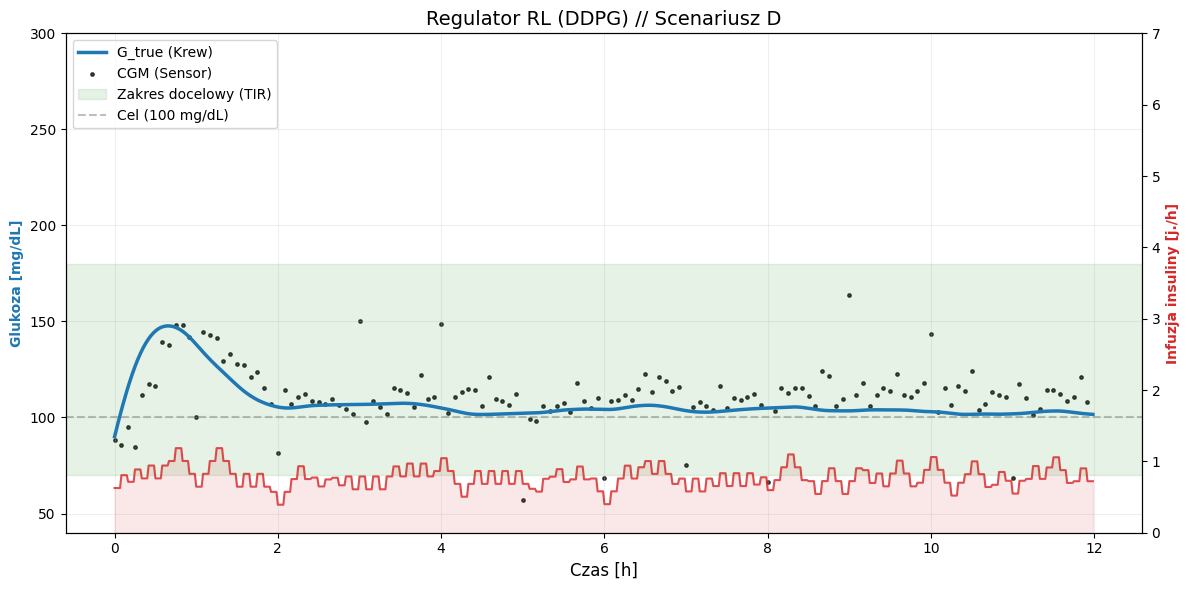

In [72]:
def simulate_rl_scenario_d(
    params,
    actor_model,
    cgm_lag_min=15,
    dt_min=1.0,
    noise_std=5.0,
    drift_per_hour=1.0,
    outlier_value=40.0
):
    """
    Scenariusz D: zakłócenia pomiaru CGM.
    Agent widzi wyłącznie opóźniony i zaburzony sygnał CGM, trend,
    estymowane działanie insuliny oraz poprzednią dawkę.
    """

    steps = int(12 * 60 / dt_min)
    time_vector = np.arange(steps) * dt_min

    lag_steps = int(cgm_lag_min / dt_min)
    decision_steps = int(5 / dt_min)

    G = np.zeros(steps)
    U = np.zeros(steps)
    CGM = np.zeros(steps)

    # Rzeczywisty stan pacjenta
    g = 90.0
    x = 0.0
    i = 0.0

    G[0] = g

    # Estymator wewnętrzny agenta
    x_est = 0.0
    i_est = 0.0

    history_cgm_seen = [100.0] * 30

    u_ddpg = 0.013
    current_cgm = 100.0

    CGM[0] = current_cgm

    actor_model.eval()

    for k in range(steps - 1):

        # ---------- 1. Zakłócony odczyt CGM ----------
        if k % decision_steps == 0:
            idx_lag = max(0, k - lag_steps)

            noise = np.random.normal(0.0, noise_std)
            drift = (k * dt_min / 60.0) * drift_per_hour

            outlier = 0.0
            if k > 0 and k % int(60 / dt_min) == 0:
                outlier = np.random.choice([-outlier_value, outlier_value])

            current_cgm = G[idx_lag] + noise + drift + outlier

            history_cgm_seen.append(current_cgm)

            CGM[k] = current_cgm

            trend = (current_cgm - history_cgm_seen[-4]) / 15.0

            state = np.array([
                current_cgm / 200.0,
                trend / 5.0,
                x_est * 100.0,
                u_ddpg / MAX_U
            ], dtype=np.float32)

            with torch.no_grad():
                u_raw = actor_model(
                    torch.FloatTensor(state).unsqueeze(0)
                ).numpy()[0, 0]

            u_ddpg = limit_insulin_change(u_raw, u_ddpg)

        else:
            CGM[k] = CGM[max(0, k - 1)]

        U[k] = u_ddpg

        # ---------- 2. Rzeczywisty model pacjenta ----------
        dG = -params["p1"] * (g - params["G_b"]) - x * g
        dX = -params["p2"] * x + params["p3"] * (i - params["I_b"])
        dI = -params["n"] * i + (1.0 / params["Vi"]) * u_ddpg

        g += dt_min * dG
        x += dt_min * dX
        i += dt_min * dI

        if g < 20.0:
            g = 20.0

        G[k + 1] = g

        # ---------- 3. Estymator działania insuliny ----------
        dX_est = -params["p2"] * x_est + params["p3"] * i_est
        dI_est = -params["n"] * i_est + (1.0 / params["Vi"]) * u_ddpg

        x_est += dt_min * dX_est
        i_est += dt_min * dI_est

    CGM[-1] = CGM[-2]
    U[-1] = U[-2]

    return pd.DataFrame({
        "time": time_vector,
        "G": G,
        "U": U,
        "CGM": CGM
    })
# Wykonanie
df_rl_d = simulate_rl_scenario_d(params, actor)

# --- GENEROWANIE WYKRESU ---
time_h = df_rl_d["time"] / 60.0
insulin_h = df_rl_d["U"] * 60.0 # j./h

fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Glukozy
ax1.set_xlabel('Czas [h]', fontsize=12)
ax1.set_ylabel('Glukoza [mg/dL]', color='tab:blue', fontweight='bold')
ax1.plot(time_h, df_rl_d["G"], color='tab:blue', label='G_true (Krew)', linewidth=2.5)
ax1.scatter(time_h[::5], df_rl_d["CGM"][::5], color='black', s=6, alpha=0.7, label='CGM (Sensor)')


#color='black', alpha=0.7, 
#         label='CGM (Sensor co 5 min)', linestyle='', marker='o', markersize=2
ax1.axhspan(70, 180, color='green', alpha=0.1, label='Zakres docelowy (TIR)')
ax1.axhline(100, color='gray', linestyle='--', alpha=0.5, label='Cel (100 mg/dL)')
ax1.set_ylim(40, 300)

# Oś Insuliny
ax2 = ax1.twinx()
ax2.set_ylabel('Infuzja insuliny [j./h]', color='tab:red', fontweight='bold')
# Zauważ: używamy plot zamiast step, bo DDPG podaje wartości ciągłe
ax2.plot(time_h, insulin_h, color='tab:red', linewidth=1.5, alpha=0.8, label='DDPG: Dawka ciągła')
ax2.fill_between(time_h, insulin_h, alpha=0.1, color='tab:red')
ax2.set_ylim(0, 7)

plt.title('Regulator RL (DDPG) // Scenariusz D', fontsize=14)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
fig.savefig("thesis-template-master\\thesis-template-master\\fig\\rl_D.pdf", bbox_inches="tight")

In [73]:
import numpy as np
import pandas as pd


def get_time_min(df):
    """
    Zwraca wektor czasu w minutach.
    Obsługuje ramki z kolumną 'time_min' lub 'time'.
    """
    if "time_min" in df.columns:
        return df["time_min"].values.astype(float)
    elif "time" in df.columns:
        return df["time"].values.astype(float)
    else:
        return np.arange(len(df), dtype=float)


def get_dt_min(df):
    """
    Wyznacza krok czasowy na podstawie kolumny czasu.
    """
    t = get_time_min(df)

    if len(t) < 2:
        return 1.0

    return float(np.median(np.diff(t)))


def count_episodes(mask):
    """
    Liczy liczbę epizodów, czyli wejść w dany stan.
    Kilka kolejnych próbek True traktowane jest jako jeden epizod.
    """
    mask = np.asarray(mask, dtype=bool)

    if len(mask) == 0:
        return 0

    starts = mask & ~np.r_[False, mask[:-1]]

    return int(starts.sum())


def time_to_stabilization_after_max_deviation(
    df,
    target=100.0,
    tolerance=10.0,
    stable_minutes=30.0
):
    """
    Czas powrotu do pasma target ± tolerance po największym odchyleniu od celu.
    Stabilizacja jest uznana dopiero wtedy, gdy glikemia pozostaje w paśmie
    przez co najmniej stable_minutes.

    Zwraca czas w minutach. Jeżeli stabilizacja nie nastąpiła, zwraca NaN.
    """
    G = df["G"].values.astype(float)
    t = get_time_min(df)
    dt = get_dt_min(df)

    stable_steps = max(1, int(stable_minutes / dt))

    # moment największego odchylenia od celu
    peak_idx = int(np.argmax(np.abs(G - target)))

    in_band = np.abs(G - target) <= tolerance

    for idx in range(peak_idx, len(G) - stable_steps + 1):
        if np.all(in_band[idx:idx + stable_steps]):
            return float(t[idx] - t[peak_idx])

    return np.nan


def compute_metrics_for_df(
    df,
    target=100.0,
    tir_low=70.0,
    tir_high=180.0,
    reaction_tolerance=10.0,
    stable_minutes=30.0
):
    """
    Oblicza kryteria oceny dla pojedynczej symulacji.
    Zakładamy, że:
    - df['G'] to rzeczywisty poziom glukozy,
    - df['U'] to podaż insuliny w j./min.
    """
    G = df["G"].values.astype(float)
    U = df["U"].values.astype(float)
    dt = get_dt_min(df)

    in_range = (G >= tir_low) & (G <= tir_high)
    below_range = G < tir_low
    above_range = G > tir_high

    tir = in_range.mean() * 100.0
    tbr = below_range.mean() * 100.0
    tar = above_range.mean() * 100.0

    mean_g = np.mean(G)
    mae_g = np.mean(np.abs(G - target))

    min_g = np.min(G)
    max_g = np.max(G)

    hypo_episodes = count_episodes(below_range)
    hyper_episodes = count_episodes(above_range)

    total_insulin = np.sum(U) * dt

    reaction_time = time_to_stabilization_after_max_deviation(
        df,
        target=target,
        tolerance=reaction_tolerance,
        stable_minutes=stable_minutes
    )

    std_g = np.std(G)
    cv_g = (std_g / mean_g) * 100.0 if mean_g != 0 else np.nan

    return {
        "TIR_%": tir,
        "TBR_%": tbr,
        "TAR_%": tar,
        "mean_G": mean_g,
        "MAE_to_target": mae_g,
        "min_G": min_g,
        "max_G": max_g,
        "hypo_episodes": hypo_episodes,
        "hyper_episodes": hyper_episodes,
        "total_insulin_U": total_insulin,
        "reaction_time_min": reaction_time,
        "std_G": std_g,
        "CV_%": cv_g
    }

In [74]:
results = {
    "PID": {
        "A": df_pid_a,
        "B": df_pid_b,
        "C": df_pid_c,
        "D": df_pid_d,
    },
    "MPC": {
        "A": df_mpc_a,
        "B": df_mpc_b,
        "C": df_mpc_c,
        "D": df_mpc_d,
    },
    "RL": {
        "A": df_rl_a,
        "B": df_rl_b,
        "C": df_rl_c,
        "D": df_rl_d,
    }
}

In [75]:
rows = []

for regulator_name, scenarios in results.items():
    for scenario_name, df in scenarios.items():
        metrics = compute_metrics_for_df(df)

        row = {
            "regulator": regulator_name,
            "scenario": scenario_name
        }

        row.update(metrics)
        rows.append(row)

metrics_by_scenario = pd.DataFrame(rows)

metrics_by_scenario

,regulator,scenario,TIR_%,TBR_%,TAR_%,mean_G,MAE_to_target,min_G,max_G,hypo_episodes,hyper_episodes,total_insulin_U,reaction_time_min,std_G,CV_%
0,PID,A,100.000000,0.000000,0.000000,101.935193,7.761313,74.189139,169.721299,0,0,10.204311,130.0,15.655537,15.358324
1,PID,B,94.444444,0.000000,5.555556,109.299914,27.060862,74.155680,249.172060,0,1,23.540209,125.0,38.257835,35.002621
2,PID,C,97.222222,2.777778,0.000000,101.786527,12.647260,65.990651,168.735560,1,0,9.017709,135.0,18.940533,18.608094
3,PID,D,97.222222,2.777778,0.000000,92.646438,15.862678,65.699073,174.625984,1,0,12.175655,95.0,19.402561,20.942587
4,MPC,A,100.000000,0.000000,0.000000,100.557003,1.974906,90.000000,128.186588,0,0,10.273830,17.0,4.925485,4.898202
5,MPC,B,68.194444,0.000000,31.805556,155.440581,55.784831,90.000000,265.217326,0,1,13.496966,NaN,58.613080,37.707707
6,MPC,C,97.638889,2.361111,0.000000,95.747345,7.503124,68.480832,134.628120,1,0,9.747831,62.0,11.335783,11.839266
7,MPC,D,100.000000,0.000000,0.000000,97.839951,5.721416,73.209666,134.628120,0,0,10.950058,108.0,8.804847,8.999235
8,RL,A,100.000000,0.000000,0.000000,109.959421,9.959421,100.000000,151.996798,0,0,9.017157,72.0,10.760151,9.785565
9,RL,B,91.111111,0.000000,8.888889,131.738266,31.802364,90.000000,218.786217,0,1,12.999806,347.0,29.228993,22.187170


In [76]:
summary = (
    metrics_by_scenario
    .groupby("regulator")
    .agg({
        "TIR_%": "mean",
        "TBR_%": "mean",
        "TAR_%": "mean",
        "mean_G": "mean",
        "MAE_to_target": "mean",
        "hypo_episodes": "sum",
        "hyper_episodes": "sum",
        "total_insulin_U": "sum",
        "reaction_time_min": "mean",
        "CV_%": "mean"
    })
    .reset_index()
)

summary

,regulator,TIR_%,TBR_%,TAR_%,mean_G,MAE_to_target,hypo_episodes,hyper_episodes,total_insulin_U,reaction_time_min,CV_%
0,MPC,91.458333,0.590278,7.951389,112.396220,17.746069,1,1,44.468685,62.333333,15.861103
1,PID,97.222222,1.388889,1.388889,101.417018,15.833028,2,1,54.937884,121.250000,22.477906
2,RL,96.562500,1.215278,2.222222,112.772906,15.779335,1,1,40.248923,138.500000,15.005492
